# 02 - Chignolin CV Transformer
Use a tensor history encoder for the peptide trajectories, then select the best CV on validation mutants and evaluate that exact checkpoint on test mutants.

In [10]:
# Requires: pip install -e .

import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from course_project.models.cv_core import CVCoreConfig, CVCoreInput, SharedCVCore
from course_project.utils import resolve_device


In [ ]:
split_seed = 12351
split_rng = np.random.default_rng(split_seed)

device = torch.device(resolve_device('cuda'))
print('device:', device)
print('split seed:', split_seed)

# Data 
peptide_dir = Path('../data/peptide')
packed_path = peptide_dir / 'hlda_trajectories_compact.pt'
tm_csv = peptide_dir / 'Tm.csv'
mfpt_csv = peptide_dir / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv'
evalue_csv = peptide_dir / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv'

# Split
train_mutant_count = 20
val_mutant_count = 5
# exclude_mutants = {'Y0R', 'D2R'}
exclude_mutants = {}

history = 1
frames_per_traj = 20000

# Model and training parms
num_runs = 2
hidden_size = 160
token_sizes = (200, 60, 8)
heads = 1
transformer_layers = 1
dropout = 0.01
batch_size = 512
learning_rate = 1e-4
weight_decay = 0.0
cls_weight = 0.3
time_lag_steps = 0
time_lag_weight = 0
epochs = 14
eval_every = 2

# Validation score weights
w_spearman = 0.7
w_pearson = 0.3


def load_target_table():
    tm_df = pd.read_csv(tm_csv)
    mfpt_df = pd.read_csv(mfpt_csv)
    evalue_df = pd.read_csv(evalue_csv)

    tm_df['Mutant'] = tm_df['Mutant'].astype(str).str.strip()
    mfpt_df['Mutant'] = mfpt_df['Mutant'].astype(str).str.strip()
    evalue_df['Mutant'] = evalue_df['Mutant'].astype(str).str.strip()

    tm_df['Tm'] = pd.to_numeric(tm_df['Tm'].astype(str).str.strip(), errors='coerce')
    mfpt_df['mfpt'] = pd.to_numeric(mfpt_df['mfpt'], errors='coerce')
    evalue_df['hlda_evalue'] = pd.to_numeric(evalue_df['hlda_evalue'], errors='coerce')

    tm_wt = float(tm_df.loc[tm_df['Mutant'].str.upper() == 'WT', 'Tm'].dropna().iloc[0])
    mfpt_wt = float(mfpt_df.loc[mfpt_df['Mutant'].str.upper() == 'WT', 'mfpt'].dropna().iloc[0])

    out = (
        tm_df[['Mutant', 'Tm']]
        .merge(mfpt_df[['Mutant', 'mfpt']], on='Mutant', how='inner')
        .merge(evalue_df[['Mutant', 'hlda_evalue']], on='Mutant', how='inner')
    )
    out['mutant'] = out['Mutant']
    out['mfpt_ratio'] = out['mfpt'] / mfpt_wt
    out['log_mfpt_ratio'] = np.log(out['mfpt_ratio'])
    return out[['mutant', 'Tm', 'mfpt', 'mfpt_ratio', 'log_mfpt_ratio', 'hlda_evalue']]


target_df = load_target_table()
target_lookup = target_df.set_index('mutant')
target_mutants = set(target_df['mutant'].astype(str).tolist())

packed = torch.load(packed_path, weights_only=False)
x_raw = packed['x'].float()
time_all = packed['time'].float()
offsets = packed['traj_offsets'].long()
labels = packed['labels'].long()
mutants = list(packed['mutants'])
feature_names_all = list(packed['feature_names'])

x_all = x_raw
feature_names = list(feature_names_all)
n_feat = int(x_all.shape[1])


def traj_slice(traj_id: int):
    s = int(offsets[traj_id])
    e = int(offsets[traj_id + 1])
    return x_all[s:e], time_all[s:e]


uniq_mutants = sorted({
    m for m in set(mutants)
    if str(m).strip().upper() not in exclude_mutants and str(m) in target_mutants
})
split_rng.shuffle(uniq_mutants)

train_mutants = list(uniq_mutants[:train_mutant_count])
val_mutants = list(uniq_mutants[train_mutant_count:train_mutant_count + val_mutant_count])
test_mutants = list(uniq_mutants[train_mutant_count + val_mutant_count:])


def ids_for_mutants(mutant_names):
    wanted = set(mutant_names)
    return [i for i, m in enumerate(mutants) if m in wanted]


train_ids = ids_for_mutants(train_mutants)
val_ids = ids_for_mutants(val_mutants)
test_ids = ids_for_mutants(test_mutants)

print('packed path:', packed_path)
print('feature count:', n_feat)
print('train mutants:', len(train_mutants), 'val mutants:', len(val_mutants), 'test mutants:', len(test_mutants))
print('train trajs:', len(train_ids), 'val trajs:', len(val_ids), 'test trajs:', len(test_ids))
print('train mutants list:', train_mutants)
print('val mutants list:', val_mutants)
print('test mutants list:', test_mutants[:10], '...')


device: cuda
split seed: 12351
packed path: ../data/peptide/hlda_trajectories_compact.pt
feature count: 29
train mutants: 15 val mutants: 10 test mutants: 12
train trajs: 30 val trajs: 20 test trajs: 24
train mutants list: ['T7Y', 'T7V', 'P3M', 'T7R', 'Y9V', 'Y9K', 'E4Y', 'T5D', 'P3R', 'T5G', 'WT', 'D2A', 'Y0A', 'Y9E', 'P3C']
val mutants list: ['P3D', 'Y9Q', 'D2Y', 'D2R', 'Y0R', 'T5R', 'T5Y', 'T7D', 'D2K', 'T7Q']
test mutants list: ['E4R', 'D2M', 'E4A', 'Y0Q', 'Y0E', 'D2N', 'E4G', 'D2C', 'Y9R', 'Y9G'] ...


In [12]:
def clip_traj(xt):
    if frames_per_traj is None:
        return xt
    return xt[:frames_per_traj]


def valid_time_range(xt, history, lag_steps):
    xt = clip_traj(xt)
    start = max(history - 1, 1)
    end = xt.shape[0] - (lag_steps if lag_steps > 0 else 1)
    return xt, start, end


def compute_norm_stats(traj_ids, history, lag_steps):
    x_sum = torch.zeros(n_feat)
    x_sq = torch.zeros(n_feat)
    x_cnt = 0
    dv_sum = torch.zeros(n_feat)
    dv_sq = torch.zeros(n_feat)
    dv_cnt = 0

    for tid in traj_ids:
        xt, _ = traj_slice(tid)
        xt, start, end = valid_time_range(xt, history, lag_steps)
        x_sum += xt.sum(dim=0)
        x_sq += (xt * xt).sum(dim=0)
        x_cnt += xt.shape[0]

        vel = xt[1:] - xt[:-1]
        dv_all = vel[1:] - vel[:-1]
        dv = dv_all[start - 1 : end - 1]
        dv_sum += dv.sum(dim=0)
        dv_sq += (dv * dv).sum(dim=0)
        dv_cnt += dv.shape[0]

    x_mean = x_sum / x_cnt
    x_var = x_sq / x_cnt - x_mean * x_mean
    x_std = torch.sqrt(torch.clamp(x_var, min=1e-8))

    dv_mean = dv_sum / dv_cnt
    dv_var = dv_sq / dv_cnt - dv_mean * dv_mean
    dv_std = torch.sqrt(torch.clamp(dv_var, min=1e-8))
    return x_mean, x_std, dv_mean, dv_std


x_mean, x_std, dv_mean, dv_std = compute_norm_stats(train_ids, history, time_lag_steps)
print('norm stats ready')


def build_split_tensors(traj_ids, history, lag_steps):
    x_hist_rows = []
    dv_rows = []
    dv_tau_rows = []
    cls_rows = []
    traj_rows = []
    sample_rows = []

    for tid in traj_ids:
        xt, _ = traj_slice(tid)
        xt, start, end = valid_time_range(xt, history, lag_steps)
        t_idx = torch.arange(start, end, dtype=torch.long)
        if t_idx.numel() == 0:
            continue

        vel = xt[1:] - xt[:-1]
        dv_all = vel[1:] - vel[:-1]
        dv = dv_all[t_idx - 1]

        if lag_steps > 0:
            tau_v = xt[t_idx + lag_steps] - xt[t_idx + lag_steps - 1]
            cur_v = xt[t_idx] - xt[t_idx - 1]
            dv_tau = (tau_v - cur_v) / float(lag_steps)
        else:
            dv_tau = torch.zeros_like(dv)

        hist_list = []
        for t in t_idx.tolist():
            hist_list.append(((xt[t - history + 1 : t + 1] - x_mean) / x_std).unsqueeze(0))
            sample_rows.append({'traj_id': int(tid), 't': int(t), 'mutant': str(mutants[tid])})
        x_hist_rows.append(torch.cat(hist_list, dim=0))
        dv_rows.append((dv - dv_mean) / dv_std)
        dv_tau_rows.append((dv_tau - dv_mean) / dv_std)

        n = int(t_idx.numel())
        cls_value = float(labels[tid])
        cls_rows.append(torch.full((n,), cls_value, dtype=torch.float32))
        traj_rows.append(torch.full((n,), int(tid), dtype=torch.long))

    x_hist = torch.cat(x_hist_rows, dim=0)
    dv = torch.cat(dv_rows, dim=0)
    dv_tau = torch.cat(dv_tau_rows, dim=0)
    y_cls = torch.cat(cls_rows, dim=0)
    traj_tensor = torch.cat(traj_rows, dim=0)
    return x_hist, dv, dv_tau, y_cls, traj_tensor, pd.DataFrame(sample_rows)


train_x, train_dv, train_dv_tau, train_cls, train_traj_id, train_samples_df = build_split_tensors(train_ids, history, time_lag_steps)
val_x, val_dv, val_dv_tau, val_cls, val_traj_id, val_samples_df = build_split_tensors(val_ids, history, time_lag_steps)
test_x, test_dv, test_dv_tau, test_cls, test_traj_id, test_samples_df = build_split_tensors(test_ids, history, time_lag_steps)

train_ds = TensorDataset(train_x, train_dv, train_dv_tau, train_cls, train_traj_id)
val_ds = TensorDataset(val_x, val_dv, val_dv_tau, val_cls, val_traj_id)
test_ds = TensorDataset(test_x, test_dv, test_dv_tau, test_cls, test_traj_id)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print('samples:', len(train_ds), len(val_ds), len(test_ds))
print('batches:', len(train_loader), len(val_loader), len(test_loader))


norm stats ready
samples: 599940 399960 479952
batches: 1172 782 938


In [13]:
class SequenceHistoryAdapter(nn.Module):
    # Treat each descriptor like a node token: token i sees the history of descriptor i.
    def __init__(self, feat_dim, history, hidden_size):
        super().__init__()
        self.in_proj = nn.Linear(history, hidden_size)
        self.desc_emb = nn.Parameter(torch.randn(feat_dim, hidden_size) * 0.01)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.in_proj.weight)
        if self.in_proj.bias is not None:
            nn.init.zeros_(self.in_proj.bias)
        nn.init.normal_(self.desc_emb, mean=0.0, std=0.01)

    def build_core_input(self, x_hist) -> CVCoreInput:
        x_desc = x_hist.transpose(1, 2)
        tokens = self.in_proj(x_desc) + self.desc_emb.unsqueeze(0)
        mask = torch.ones(tokens.size(0), tokens.size(1), dtype=torch.bool, device=tokens.device)
        return CVCoreInput(tokens=tokens, mask=mask, local_skip=tokens)


class ChignolinCVModel(nn.Module):
    def __init__(self, feat_dim, history, hidden, token_sizes, heads, token_layers, dropout):
        super().__init__()
        self.adapter = SequenceHistoryAdapter(feat_dim, history, hidden)
        self.core = SharedCVCore(
            CVCoreConfig(
                hidden_size=hidden,
                output_dim=1,
                transformer_layers=token_layers,
                transformer_heads=heads,
                transformer_dropout=dropout,
                token_sizes=token_sizes,
                use_local_skip=True,
            )
        )
        self.cls_head = nn.Sequential(
            nn.Linear(token_sizes[-1], hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.reset_parameters()

    def reset_parameters(self):
        for seq in (self.cls_head,):
            for module in seq.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        nn.init.zeros_(module.bias)

    def forward(self, x_hist):
        core_input = self.adapter.build_core_input(x_hist)
        output = self.core(core_input)
        cv = output.cv
        cls_logit = self.cls_head(cv).squeeze(-1)
        tau_pred = self.core.predict_tau(core_input).squeeze(-1)
        return output.prediction.squeeze(-1), tau_pred, cls_logit, cv


In [14]:
def run_epoch(loader, train_mode=True):
    model.train(train_mode)
    loss_sum = 0.0
    dv_loss_sum = 0.0
    tau_loss_sum = 0.0
    cls_loss_sum = 0.0
    n = 0
    y_true = []
    y_prob = []

    for xh, y_dv, y_tau, y_cls, traj_id in loader:
        xh = xh.to(device)
        y_dv = y_dv.to(device)
        y_tau = y_tau.to(device)
        y_cls = y_cls.to(device)
        traj_id = traj_id.to(device)

        with torch.set_grad_enabled(train_mode):
            dv_pred, tau_pred, cls_logit, cv = model(xh)
            loss_dv = F.mse_loss(dv_pred, y_dv)
            if time_lag_steps > 0 and time_lag_weight > 0:
                loss_tau = F.mse_loss(tau_pred, y_tau)
                loss = loss_dv + time_lag_weight * loss_tau
            else:
                loss_tau = torch.zeros((), device=loss_dv.device)
                loss = loss_dv
            if cls_weight > 0:
                loss_cls = F.binary_cross_entropy_with_logits(cls_logit, y_cls)
                loss = loss + cls_weight * loss_cls
            else:
                loss_cls = torch.zeros((), device=loss_dv.device)
            if train_mode:
                opt.zero_grad()
                loss.backward()
                opt.step()

        b = xh.size(0)
        n += b
        loss_sum += loss.item() * b
        dv_loss_sum += loss_dv.item() * b
        tau_loss_sum += loss_tau.item() * b
        cls_loss_sum += loss_cls.item() * b
        y_true.append(y_cls.detach().cpu())
        y_prob.append(torch.sigmoid(cls_logit).detach().cpu())

    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    y_pred = (y_prob >= 0.5).astype(np.int64)

    out = {
        'loss': loss_sum / n,
        'dv_mse': dv_loss_sum / n,
        'tau_mse': tau_loss_sum / n,
        'cls_bce': cls_loss_sum / n,
        'cls_acc': float((y_pred == y_true).mean()) if cls_weight > 0 else float('nan'),
    }
    return out


@torch.no_grad()
def cv_summary_df_from_split(x_tensor, sample_df):
    model.eval()
    cv_rows = []
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False, drop_last=False)
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model(xh)
        cv_rows.append(cv.detach().cpu())
    cv_all = torch.cat(cv_rows, dim=0).numpy()
    cv_df = sample_df.copy().reset_index(drop=True)
    cv_cols = []
    for i in range(cv_all.shape[1]):
        col = f'CV{i + 1}'
        cv_df[col] = cv_all[:, i]
        cv_cols.append(col)
    return cv_df.groupby('mutant', as_index=False)[cv_cols].mean()

def merged_cv_target_for_split(x_tensor, sample_df):
    cv_df = cv_summary_df_from_split(x_tensor, sample_df)
    return cv_df.merge(target_df, on='mutant', how='inner')


@torch.no_grad()
def cv_frame_df_from_split(x_tensor, sample_df):
    model.eval()
    cv_rows = []
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False, drop_last=False)
    for (xh,) in loader:
        xh = xh.to(device)
        _, _, _, cv = model(xh)
        cv_rows.append(cv.detach().cpu())
    cv_all = torch.cat(cv_rows, dim=0).numpy()
    cv_df = sample_df.copy().reset_index(drop=True)
    for i in range(cv_all.shape[1]):
        cv_df[f'CV{i + 1}'] = cv_all[:, i]
    return cv_df


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size < 3:
        return float('nan')
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return float('nan')
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    if ss_tot <= 1e-12:
        return float('nan')
    return float(1.0 - ss_res / ss_tot)


def best_metric_from_merged(merged, metric):
    cv_cols = [c for c in merged.columns if c.startswith('CV')]
    best = {'score': float('-inf'), 'r2': float('nan'), 'cv': None, 'n': 0, 'spearman': float('nan'), 'pearson': float('nan')}
    for cv in cv_cols:
        sub = merged[[cv, metric]].dropna()
        n = int(len(sub))
        if n < 3:
            continue
        s = float(sub[cv].corr(sub[metric], method='spearman'))
        p = float(sub[cv].corr(sub[metric], method='pearson'))
        r2 = fit_r2(sub[cv].to_numpy(), sub[metric].to_numpy())
        score = w_spearman * abs(s) + w_pearson * abs(p)
        if not np.isfinite(score):
            continue
        if score > best['score']:
            best = {'score': float(score), 'r2': float(r2), 'cv': cv, 'n': n, 'spearman': float(s), 'pearson': float(p)}
    return best


history_rows = []
val_metric_rows = []
selection_rows = []
selected_test_payload = {}
metrics = ['Tm', 'log_mfpt_ratio', 'hlda_evalue']
best_by_metric = {
    metric: {
        'score': float('-inf'),
        'r2': float('nan'),
        'epoch': None,
        'cv': None,
        'spearman': float('nan'),
        'pearson': float('nan'),
        'run_idx': None,
        'run_seed': None,
        'path': None,
    }
    for metric in metrics
}

run_dir = Path('../results') / 'chignolin_cv_transformer'
run_dir.mkdir(parents=True, exist_ok=True)

for run_idx in range(1, num_runs + 1):
    run_seed = int(torch.seed() % (2**32 - 1))
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    model = ChignolinCVModel(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        token_sizes=token_sizes,
        heads=heads,
        token_layers=transformer_layers,
        dropout=dropout,
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    run_ckpt_dir = run_dir / f'run_{run_idx:02d}'
    run_ckpt_dir.mkdir(parents=True, exist_ok=True)
    print(f'run {run_idx}/{num_runs} seed={run_seed}')
    print('shared core token sizes:', model.core.token_sizes)
    print(f'time-lag steps={time_lag_steps} lambda={time_lag_weight}')

    for epoch in range(1, epochs + 1):
        tr = run_epoch(train_loader, train_mode=True)
        va = run_epoch(val_loader, train_mode=False)
        history_rows.append({
            'run_idx': run_idx,
            'run_seed': run_seed,
            'epoch': epoch,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'train_dv_mse': tr['dv_mse'],
            'val_dv_mse': va['dv_mse'],
            'train_tau_mse': tr['tau_mse'],
            'val_tau_mse': va['tau_mse'],
        })

        if epoch % eval_every != 0:
            print(
                f"[run {run_idx:02d} ep {epoch:>3}/{epochs}] "
                f"tr={tr['loss']:.3g} va={va['loss']:.3g} "
                f"tau_mse={tr['tau_mse']:.3g}/{va['tau_mse']:.3g}"
            )
            continue

        merged_val = merged_cv_target_for_split(val_x, val_samples_df)
        ckpt_path = run_ckpt_dir / f'epoch_{epoch:04d}.pt'
        torch.save({'run_idx': run_idx, 'run_seed': run_seed, 'epoch': epoch, 'model_state_dict': model.state_dict()}, ckpt_path)

        best_text = 'none'
        best_score = float('-inf')
        for metric in metrics:
            best = best_metric_from_merged(merged_val, metric)
            val_metric_rows.append({
                'run_idx': run_idx,
                'run_seed': run_seed,
                'epoch': epoch,
                'metric': metric,
                'val_best_score': float(best['score']),
                'val_best_r2': float(best['r2']),
                'val_best_cv': best['cv'],
                'val_best_spearman': float(best['spearman']),
                'val_best_pearson': float(best['pearson']),
                'val_n': int(best['n']),
            })
            if np.isfinite(best['score']) and best['score'] > best_by_metric[metric]['score']:
                best_by_metric[metric] = {
                    'score': float(best['score']),
                    'r2': float(best['r2']),
                    'epoch': epoch,
                    'cv': best['cv'],
                    'spearman': float(best['spearman']),
                    'pearson': float(best['pearson']),
                    'run_idx': run_idx,
                    'run_seed': run_seed,
                    'path': str(ckpt_path),
                }
            if np.isfinite(best['score']) and best['score'] > best_score:
                best_score = float(best['score'])
                best_text = (
                    f"{metric}/{best['cv']} score={best['score']:.3g} "
                    f"R2={best['r2']:.3g} |S|={abs(best['spearman']):.3g} |P|={abs(best['pearson']):.3g}"
                )

        print(
            f"[run {run_idx:02d} ep {epoch:>3}/{epochs}] "
            f"tr={tr['loss']:.3g} va={va['loss']:.3g} "
            f"tau_mse={tr['tau_mse']:.3g}/{va['tau_mse']:.3g} "
            f"best_cv={best_text}"
        )

history_df = pd.DataFrame(history_rows)
val_metric_history_df = pd.DataFrame(val_metric_rows)

for metric in metrics:
    best = best_by_metric[metric]
    ckpt = torch.load(best['path'], map_location='cpu', weights_only=False)
    model = ChignolinCVModel(
        feat_dim=n_feat,
        history=history,
        hidden=hidden_size,
        token_sizes=token_sizes,
        heads=heads,
        token_layers=transformer_layers,
        dropout=dropout,
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])

    val_merged = merged_cv_target_for_split(val_x, val_samples_df)
    test_merged = merged_cv_target_for_split(test_x, test_samples_df)
    cv_col = best['cv']
    val_sub = val_merged[[cv_col, metric, 'mutant']].dropna()
    test_sub = test_merged[[cv_col, metric, 'mutant']].dropna()
    val_r2 = fit_r2(val_sub[cv_col].to_numpy(), val_sub[metric].to_numpy())
    test_r2 = fit_r2(test_sub[cv_col].to_numpy(), test_sub[metric].to_numpy())
    val_s = float(val_sub[cv_col].corr(val_sub[metric], method='spearman'))
    val_p = float(val_sub[cv_col].corr(val_sub[metric], method='pearson'))
    test_s = float(test_sub[cv_col].corr(test_sub[metric], method='spearman'))
    test_p = float(test_sub[cv_col].corr(test_sub[metric], method='pearson'))

    selection_rows.append({
        'metric': metric,
        'best_run': int(best['run_idx']),
        'run_seed': int(best['run_seed']),
        'best_epoch': int(best['epoch']),
        'best_cv': cv_col,
        'val_score': float(best['score']),
        'val_r2': val_r2,
        'val_spearman': val_s,
        'val_pearson': val_p,
        'test_r2': test_r2,
        'test_spearman': test_s,
        'test_pearson': test_p,
        'test_n': int(len(test_sub)),
        'checkpoint_path': best['path'],
    })
    selected_test_payload[metric] = {
        'best_run': int(best['run_idx']),
        'run_seed': int(best['run_seed']),
        'best_epoch': int(best['epoch']),
        'cv': cv_col,
        'val_merged': val_merged,
        'test_merged': test_merged,
        'val_score': float(best['score']),
        'val_r2': val_r2,
        'val_spearman': val_s,
        'val_pearson': val_p,
        'test_r2': test_r2,
        'test_spearman': test_s,
        'test_pearson': test_p,
    }

selection_summary_df = pd.DataFrame(selection_rows)
history_df.to_csv(run_dir / 'history.csv', index=False)
val_metric_history_df.to_csv(run_dir / 'val_metric_history.csv', index=False)
selection_summary_df.to_csv(run_dir / 'selection_summary.csv', index=False)
print(selection_summary_df)



run 1/2 seed=1880741568
shared core token sizes: [200, 60, 8]
time-lag steps=0 lambda=0
[run 01 ep   1/30] tr=0.986 va=0.967 tau_mse=0/0
[run 01 ep   2/30] tr=0.967 va=0.967 tau_mse=0/0 best_cv=Tm/CV7 score=0.75 R2=0.577 |S|=0.745 |P|=0.76
[run 01 ep   3/30] tr=0.964 va=0.967 tau_mse=0/0
[run 01 ep   4/30] tr=0.963 va=0.965 tau_mse=0/0 best_cv=Tm/CV4 score=0.707 R2=0.491 |S|=0.709 |P|=0.701
[run 01 ep   5/30] tr=0.962 va=0.965 tau_mse=0/0
[run 01 ep   6/30] tr=0.962 va=0.962 tau_mse=0/0 best_cv=Tm/CV6 score=0.739 R2=0.607 |S|=0.721 |P|=0.779
[run 01 ep   7/30] tr=0.96 va=0.963 tau_mse=0/0
[run 01 ep   8/30] tr=0.96 va=0.961 tau_mse=0/0 best_cv=Tm/CV7 score=0.662 R2=0.483 |S|=0.648 |P|=0.695
[run 01 ep   9/30] tr=0.959 va=0.965 tau_mse=0/0
[run 01 ep  10/30] tr=0.959 va=0.961 tau_mse=0/0 best_cv=Tm/CV6 score=0.789 R2=0.695 |S|=0.77 |P|=0.834
[run 01 ep  11/30] tr=0.957 va=0.961 tau_mse=0/0
[run 01 ep  12/30] tr=0.957 va=0.961 tau_mse=0/0 best_cv=Tm/CV6 score=0.76 R2=0.628 |S|=0.745 |P|=

KeyboardInterrupt: 

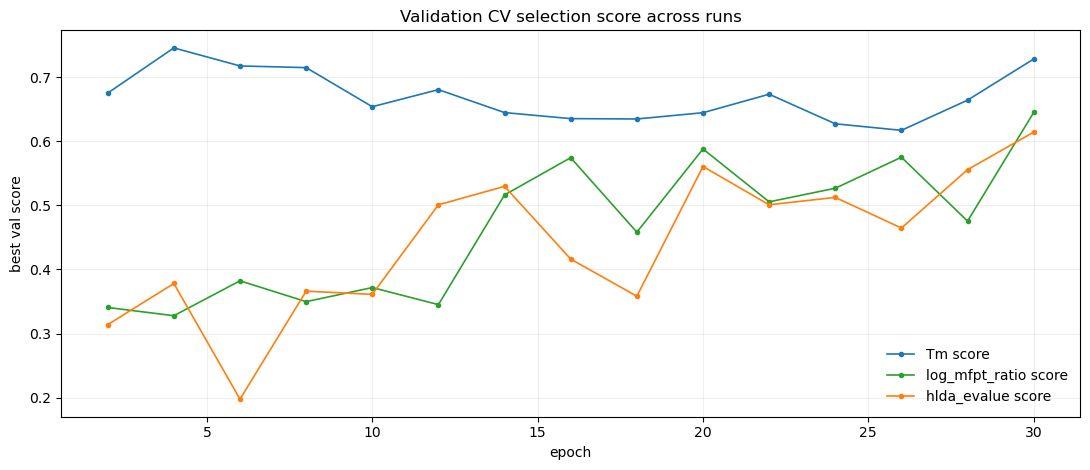

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for metric, color in [('Tm', 'tab:blue'), ('log_mfpt_ratio', 'tab:green'), ('hlda_evalue', 'tab:orange')]:
    sub = val_metric_history_df[val_metric_history_df['metric'] == metric]
    best_per_epoch = sub.groupby('epoch', as_index=False)[['val_best_score', 'val_best_r2']].max().sort_values('epoch')
    ax.plot(best_per_epoch['epoch'], best_per_epoch['val_best_score'], marker='o', ms=3, lw=1.2, color=color, label=f'{metric} score')
ax.set_xlabel('epoch')
ax.set_ylabel('best val score')
ax.set_title('Validation CV selection score across runs')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

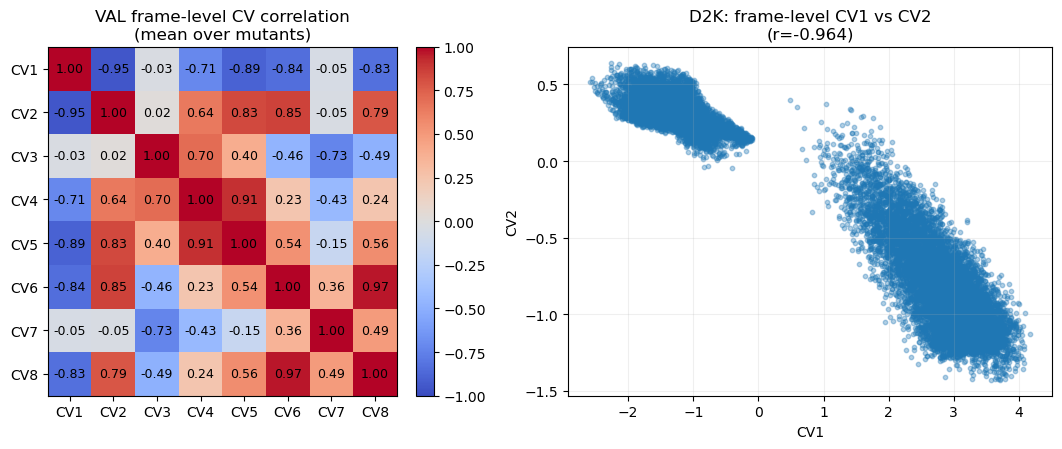

In [ ]:
frame_cv_df = cv_frame_df_from_split(val_x, val_samples_df)
cv_cols = [c for c in frame_cv_df.columns if c.startswith('CV')]

frame_corrs = []
for mutant, sub in frame_cv_df.groupby('mutant'):
    if len(sub) < 3:
        continue
    corr = sub[cv_cols].corr(method='pearson').to_numpy(dtype=float)
    frame_corrs.append(corr)

mean_frame_corr = np.mean(np.stack(frame_corrs, axis=0), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
im = axes[0].imshow(mean_frame_corr, vmin=-1.0, vmax=1.0, cmap='coolwarm')
axes[0].set_xticks(range(len(cv_cols)), cv_cols)
axes[0].set_yticks(range(len(cv_cols)), cv_cols)
axes[0].set_title('VAL frame-level CV correlation\n(mean over mutants)')
for i in range(len(cv_cols)):
    for j in range(len(cv_cols)):
        axes[0].text(j, i, f'{mean_frame_corr[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

example_mutant = str(frame_cv_df['mutant'].iloc[0])
example_df = frame_cv_df[frame_cv_df['mutant'] == example_mutant].copy()
if len(cv_cols) >= 2:
    axes[1].scatter(example_df[cv_cols[0]], example_df[cv_cols[1]], s=10, alpha=0.35)
    r = float(example_df[cv_cols[0]].corr(example_df[cv_cols[1]], method='pearson'))
    axes[1].set_xlabel(cv_cols[0])
    axes[1].set_ylabel(cv_cols[1])
    axes[1].set_title(f'{example_mutant}: frame-level {cv_cols[0]} vs {cv_cols[1]}\n(r={r:.3f})')
    axes[1].grid(alpha=0.2)
else:
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


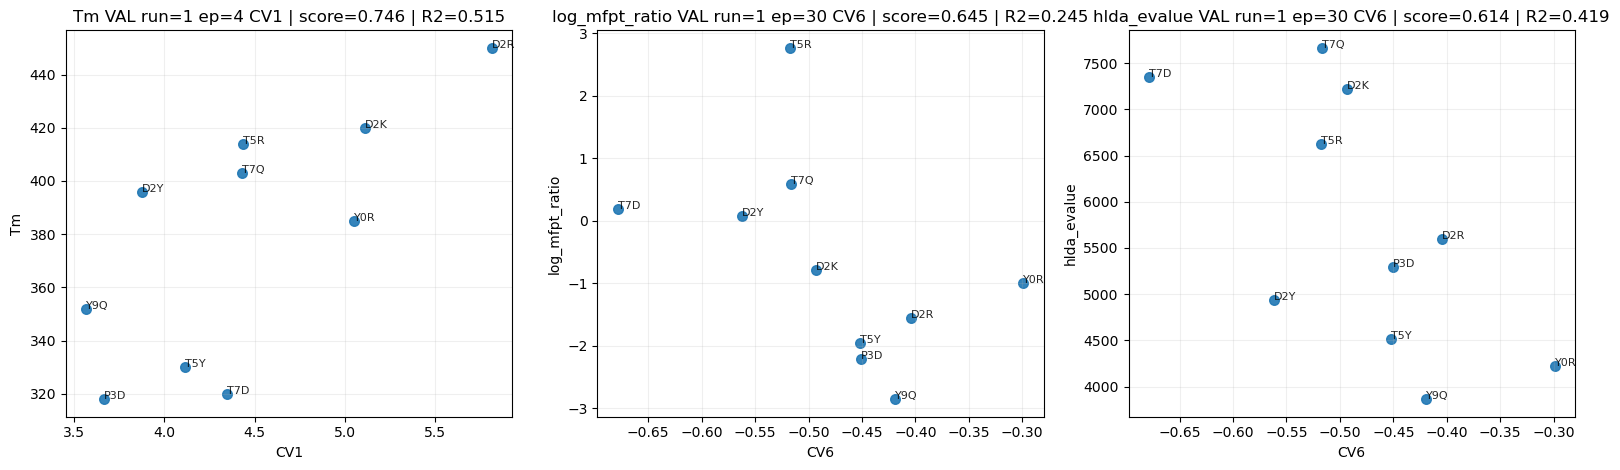

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, metric in zip(np.asarray(axes).reshape(-1), ['Tm', 'log_mfpt_ratio', 'hlda_evalue']):
    payload = selected_test_payload.get(metric)
    if payload is None:
        ax.set_axis_off()
        continue
    cv = payload['cv']
    sub = payload['val_merged'][[cv, metric, 'mutant']].dropna()
    ax.scatter(sub[cv], sub[metric], s=48, alpha=0.9)
    for _, r in sub.iterrows():
        ax.text(r[cv], r[metric], str(r['mutant']), fontsize=8, alpha=0.85)
    ax.set_title(
        f"{metric} VAL run={payload['best_run']} ep={payload['best_epoch']} {cv} "
        f"| score={payload['val_score']:.3f} | R2={payload['val_r2']:.3f}"
    )
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()



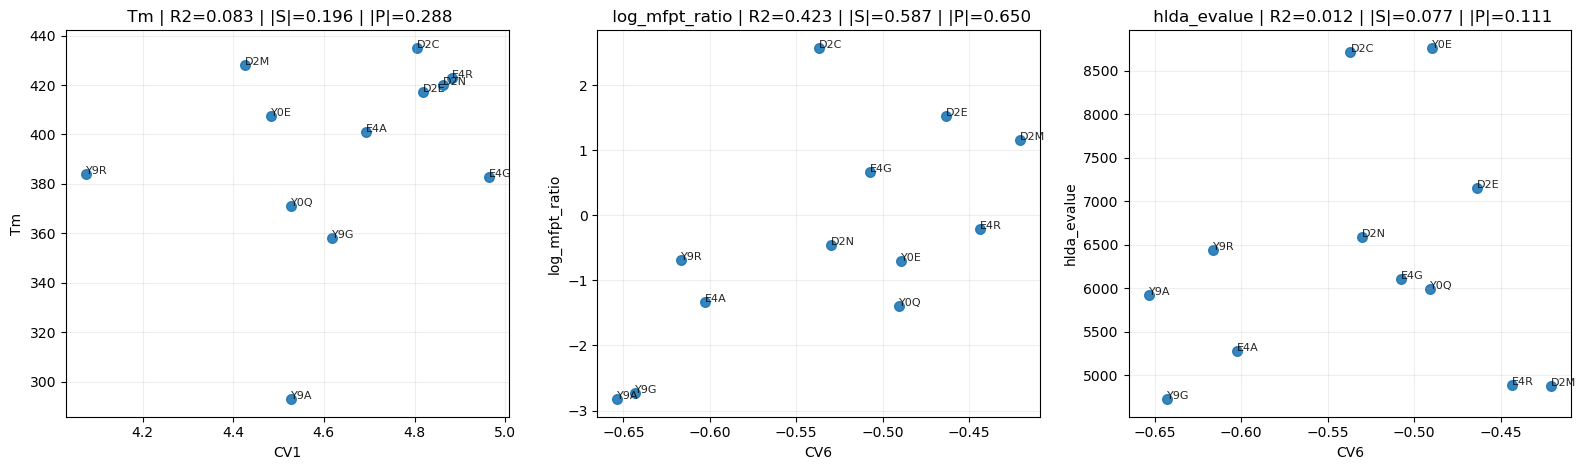

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, metric in zip(np.asarray(axes).reshape(-1), ['Tm', 'log_mfpt_ratio', 'hlda_evalue']):
    payload = selected_test_payload.get(metric)
    if payload is None:
        ax.set_axis_off()
        continue
    cv = payload['cv']
    sub = payload['test_merged'][[cv, metric, 'mutant']].dropna()
    ax.scatter(sub[cv], sub[metric], s=48, alpha=0.9)
    for _, r in sub.iterrows():
        ax.text(r[cv], r[metric], str(r['mutant']), fontsize=8, alpha=0.85)
    ax.set_title(
        # f" run={payload['best_run']} ep={payload['best_epoch']} {cv} "
        f" {metric} | R2={payload['test_r2']:.3f} | |S|={abs(payload['test_spearman']):.3f} | |P|={abs(payload['test_pearson']):.3f}"
    )
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

